# Information Spread Simulation and Toxicity Propagation Analysis

This notebook simulates how toxicity spreads across the Reddit network using different propagation models.

## Objectives:
- Simulate toxicity spread using Independent Cascade and SIS models
- Measure spread speed and reach
- Analyze influence of toxic hubs
- Track affected communities over time
- Create visualizations and animations of toxicity propagation

## 1. Import Required Libraries

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pyvis.network import Network
import random
import os
from collections import defaultdict
import json

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Graph and Toxicity Data

In [3]:
# Load the directed graph
GRAPH_PATH = 'data/processed/directed_graph.graphml'
G = nx.read_graphml(GRAPH_PATH)

print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Load toxicity scores
toxicity_df = pd.read_csv('../outputs/toxicity_scores.csv')
toxic_subreddit_df = pd.read_csv('../outputs/toxic_subreddits.csv')

print(f"\nToxicity data loaded: {len(toxicity_df)} nodes with toxicity scores")
print(f"Toxic subreddits: {len(toxic_subreddit_df)}")

# Load community detection results
community_df = pd.read_csv('results/community_labels.csv')
print(f"Community data loaded: {len(community_df)} communities")

Graph loaded: 35777 nodes, 137821 edges

Toxicity data loaded: 35776 nodes with toxicity scores
Toxic subreddits: 20
Community data loaded: 35777 communities


## 3. Independent Cascade Model

The Independent Cascade Model simulates how toxicity spreads through the network.
- Each toxic node attempts to infect neighbors with independent probability
- Once activated, a node remains toxic forever

In [4]:
def independent_cascade_model(G, initial_infected, propagation_prob=0.1, max_iterations=100):
    """
    Simulate toxicity spread using Independent Cascade Model
    
    Args:
        G: NetworkX graph
        initial_infected: list of initially infected nodes
        propagation_prob: probability of infection spreading to neighbor
        max_iterations: maximum simulation steps
    
    Returns:
        infected_history: list showing infected count at each time step
        final_infected: set of all infected nodes at end
    """
    infected = set(initial_infected)
    newly_infected = set(initial_infected)
    infected_history = [len(infected)]
    
    for iteration in range(max_iterations):
        next_infected = set()
        
        # Each newly infected node tries to infect its neighbors
        for node in newly_infected:
            neighbors = list(G.successors(node))  # outgoing edges (directed graph)
            for neighbor in neighbors:
                if neighbor not in infected:
                    if random.random() < propagation_prob:
                        next_infected.add(neighbor)
        
        if len(next_infected) == 0:
            break
            
        infected.update(next_infected)
        newly_infected = next_infected
        infected_history.append(len(infected))
    
    return infected_history, infected

# Select toxic hubs as initial spreaders
top_toxic = toxic_subreddit_df.nlargest(5, 'normalized_toxicity')['Subreddit Node'].tolist()
print(f"Top toxic hubs selected: {top_toxic}")

# Run Independent Cascade simulation
ic_history, ic_infected = independent_cascade_model(G, top_toxic, propagation_prob=0.15)

print(f"\nIndependent Cascade Results:")
print(f"Initial infected: {len(top_toxic)}")
print(f"Final infected: {len(ic_infected)}")
print(f"Spread ratio: {len(ic_infected) / G.number_of_nodes():.2%}")
print(f"Propagation timeline: {ic_history[:20]}")

Top toxic hubs selected: ['tomorrow', 'macsucks', 'otheroffmychest', 'enoughpaulspam', 'rice']

Independent Cascade Results:
Initial infected: 5
Final infected: 4779
Spread ratio: 13.36%
Propagation timeline: [5, 6, 13, 43, 218, 1148, 2851, 4096, 4605, 4722, 4768, 4776, 4779]


## 4. SIS (Susceptible-Infected-Susceptible) Model

The SIS Model simulates disease-like spread where nodes can recover.
- Infected nodes can recover and become susceptible again
- This better models temporary toxic behavior that can spread and decrease

In [5]:
def sis_model(G, initial_infected, infection_prob=0.1, recovery_prob=0.05, max_iterations=100):
    """
    Simulate toxicity spread using SIS Model
    
    Args:
        G: NetworkX graph
        initial_infected: list of initially infected nodes
        infection_prob: probability of infection spreading to neighbor
        recovery_prob: probability of infected node recovering
        max_iterations: maximum simulation steps
    
    Returns:
        infected_history: list showing infected count at each time step
        final_infected: set of currently infected nodes at end
    """
    infected = set(initial_infected)
    infected_history = [len(infected)]
    
    for iteration in range(max_iterations):
        # Recovery phase: some infected nodes recover
        recovered = set()
        for node in infected:
            if random.random() < recovery_prob:
                recovered.add(node)
        
        infected -= recovered
        
        # Infection phase: infected nodes try to infect neighbors
        new_infected = set()
        for node in infected:
            neighbors = list(G.successors(node))
            for neighbor in neighbors:
                if neighbor not in infected:
                    if random.random() < infection_prob:
                        new_infected.add(neighbor)
        
        infected.update(new_infected)
        infected_history.append(len(infected))
        
        # Stop if no infected nodes
        if len(infected) == 0:
            break
    
    return infected_history, infected

# Run SIS Model simulation
sis_history, sis_infected = sis_model(G, top_toxic, infection_prob=0.12, recovery_prob=0.08)

print(f"SIS Model Results:")
print(f"Initial infected: {len(top_toxic)}")
print(f"Final infected: {len(sis_infected)}")
print(f"Average infected: {np.mean(sis_history):.1f}")
print(f"Peak infected: {max(sis_history)}")
print(f"Infection timeline: {sis_history[:20]}")

SIS Model Results:
Initial infected: 5
Final infected: 13422
Average infected: 11976.1
Peak infected: 13540
Infection timeline: [5, 5, 11, 27, 201, 984, 2489, 4350, 6023, 7303, 8361, 9299, 10010, 10643, 11097, 11462, 11824, 12038, 12211, 12335]


## 5. Measure Spread Metrics

In [6]:
def calculate_spread_metrics(history, initial_size):
    """Calculate metrics from spread simulation history"""
    metrics = {
        'peak_infected': max(history),
        'final_infected': history[-1],
        'initial_infected': initial_size,
        'spread_ratio': history[-1] / G.number_of_nodes(),
        'peak_time': np.argmax(history),
        'average_infected': np.mean(history),
        'spread_speed': np.mean(np.diff(history[:20])) if len(history) > 1 else 0
    }
    return metrics

# Calculate metrics for both models
ic_metrics = calculate_spread_metrics(ic_history, len(top_toxic))
sis_metrics = calculate_spread_metrics(sis_history, len(top_toxic))

print("INDEPENDENT CASCADE MODEL METRICS:")
print(f"  Peak infected nodes: {ic_metrics['peak_infected']}")
print(f"  Final spread ratio: {ic_metrics['spread_ratio']:.2%}")
print(f"  Time to peak: {ic_metrics['peak_time']} steps")
print(f"  Average infected: {ic_metrics['average_infected']:.1f}")
print(f"  Spread speed: {ic_metrics['spread_speed']:.2f} nodes/step")

print("\nSIS MODEL METRICS:")
print(f"  Peak infected nodes: {sis_metrics['peak_infected']}")
print(f"  Final infected nodes: {sis_metrics['final_infected']}")
print(f"  Average infected: {sis_metrics['average_infected']:.1f}")
print(f"  Peak time: {sis_metrics['peak_time']} steps")

INDEPENDENT CASCADE MODEL METRICS:
  Peak infected nodes: 4779
  Final spread ratio: 13.36%
  Time to peak: 12 steps
  Average infected: 2463.8
  Spread speed: 397.83 nodes/step

SIS MODEL METRICS:
  Peak infected nodes: 13540
  Final infected nodes: 13422
  Average infected: 11976.1
  Peak time: 78 steps


## 6. Analyze Affected Communities

In [8]:
from collections import defaultdict

# Create fast lookup: subreddit -> community
subreddit_to_community = {}

if 'community' in community_df.columns:
    community_map = community_df.set_index('node')['community'].to_dict()

    for subreddit in toxicity_df['Subreddit Node']:
        if subreddit in community_map:
            subreddit_to_community[subreddit] = int(community_map[subreddit])


def analyze_affected_communities(infected_nodes):
    """Analyze which communities are affected by spread"""
    
    affected_communities = defaultdict(int)

    for node in infected_nodes:
        community = subreddit_to_community.get(node)

        if community is not None:
            affected_communities[community] += 1

    return affected_communities


# Analyze IC model
affected_communities_ic = analyze_affected_communities(ic_infected)

print(f"Independent Cascade Model - Affected Communities: {len(affected_communities_ic)}")
print(
    f"  Top communities: "
    f"{sorted(affected_communities_ic.items(), key=lambda x: x[1], reverse=True)[:5]}"
)

# Analyze SIS model
affected_communities_sis = analyze_affected_communities(sis_infected)

print(f"\nSIS Model - Affected Communities: {len(affected_communities_sis)}")
print(
    f"  Top communities: "
    f"{sorted(affected_communities_sis.items(), key=lambda x: x[1], reverse=True)[:5]}"
)

Independent Cascade Model - Affected Communities: 36
  Top communities: [(7, 815), (1, 736), (5, 689), (11, 567), (2, 327)]

SIS Model - Affected Communities: 45
  Top communities: [(7, 1958), (5, 1889), (1, 1715), (11, 1420), (2, 804)]


## 7. Visualization 1: Spread Over Time

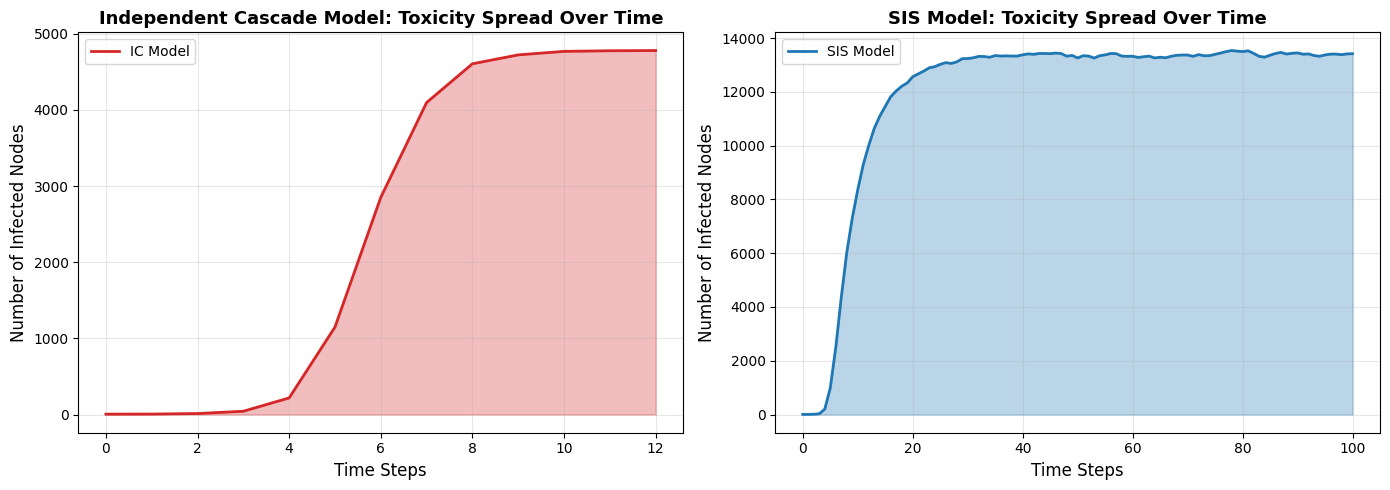

Spread visualization saved!


In [9]:
# Plot spread dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Independent Cascade
axes[0].plot(ic_history, linewidth=2, color='#d62728', label='IC Model')
axes[0].fill_between(range(len(ic_history)), ic_history, alpha=0.3, color='#d62728')
axes[0].set_xlabel('Time Steps', fontsize=12)
axes[0].set_ylabel('Number of Infected Nodes', fontsize=12)
axes[0].set_title('Independent Cascade Model: Toxicity Spread Over Time', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# SIS Model
axes[1].plot(sis_history, linewidth=2, color='#1f77b4', label='SIS Model')
axes[1].fill_between(range(len(sis_history)), sis_history, alpha=0.3, color='#1f77b4')
axes[1].set_xlabel('Time Steps', fontsize=12)
axes[1].set_ylabel('Number of Infected Nodes', fontsize=12)
axes[1].set_title('SIS Model: Toxicity Spread Over Time', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/spread_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("Spread visualization saved!")

## 8. Visualization 2: Model Comparison

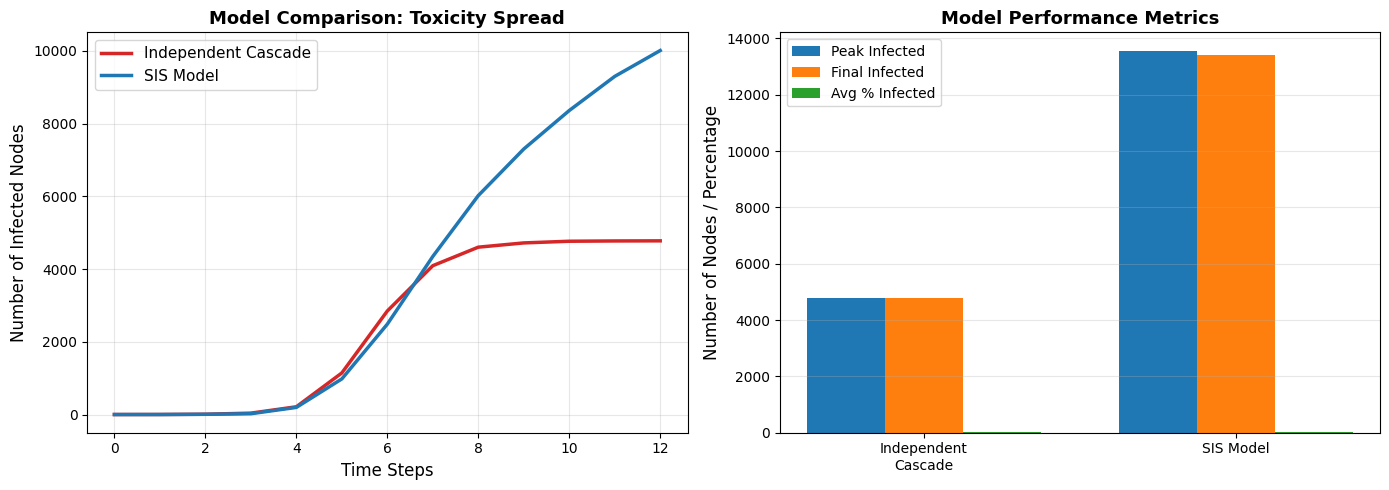

Model comparison saved!


In [10]:
# Compare both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlay comparison
steps_to_show = min(50, len(ic_history), len(sis_history))
axes[0].plot(ic_history[:steps_to_show], linewidth=2.5, label='Independent Cascade', color='#d62728')
axes[0].plot(sis_history[:steps_to_show], linewidth=2.5, label='SIS Model', color='#1f77b4')
axes[0].set_xlabel('Time Steps', fontsize=12)
axes[0].set_ylabel('Number of Infected Nodes', fontsize=12)
axes[0].set_title('Model Comparison: Toxicity Spread', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Metrics comparison
models = ['Independent\nCascade', 'SIS Model']
metrics_data = [
    [ic_metrics['peak_infected'], sis_metrics['peak_infected']],
    [ic_metrics['final_infected'], sis_metrics['final_infected']],
    [ic_metrics['spread_ratio']*100, sis_metrics['average_infected']/G.number_of_nodes()*100]
]

x = np.arange(len(models))
width = 0.25
for i, label in enumerate(['Peak Infected', 'Final Infected', 'Avg % Infected']):
    axes[1].bar(x + i*width, metrics_data[i], width, label=label)

axes[1].set_ylabel('Number of Nodes / Percentage', fontsize=12)
axes[1].set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison saved!")

## 9. Visualization 3: Toxic Hubs Influence

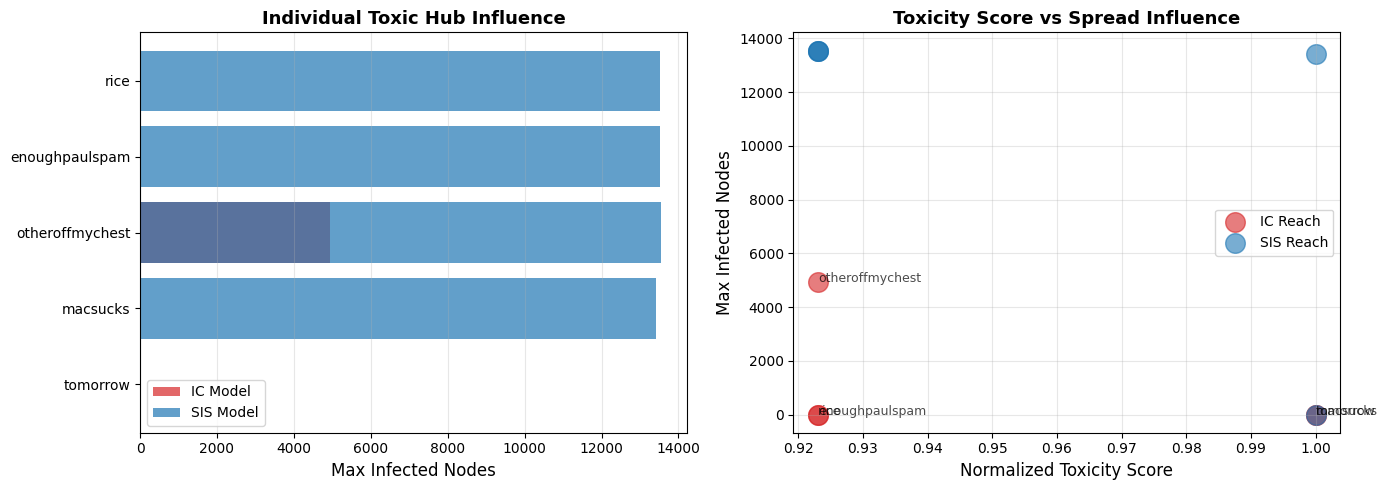

Toxic hubs influence analysis saved!

Influence Analysis Summary:
              node  ic_reach  sis_reach  toxicity
0         tomorrow         1          1  1.000000
1         macsucks         1      13420  1.000000
2  otheroffmychest      4943      13550  0.923077
3   enoughpaulspam         1      13531  0.923077
4             rice         1      13529  0.923077


In [11]:
# Analyze influence of individual toxic hubs
influence_analysis = []

for node in top_toxic:
    # Test spread starting from single node
    ic_single, _ = independent_cascade_model(G, [node], propagation_prob=0.15)
    sis_single, _ = sis_model(G, [node], infection_prob=0.12, recovery_prob=0.08)
    
    influence_analysis.append({
        'node': node,
        'ic_reach': max(ic_single),
        'sis_reach': max(sis_single),
        'toxicity': toxic_subreddit_df[toxic_subreddit_df['Subreddit Node'] == node]['normalized_toxicity'].values[0] if len(toxic_subreddit_df[toxic_subreddit_df['Subreddit Node'] == node]) > 0 else 0
    })

influence_df = pd.DataFrame(influence_analysis)

# Plot toxic hub influence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual influence
axes[0].barh(influence_df['node'], influence_df['ic_reach'], color='#d62728', alpha=0.7, label='IC Model')
axes[0].barh(influence_df['node'], influence_df['sis_reach'], color='#1f77b4', alpha=0.7, label='SIS Model')
axes[0].set_xlabel('Max Infected Nodes', fontsize=12)
axes[0].set_title('Individual Toxic Hub Influence', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Toxicity vs Reach
axes[1].scatter(influence_df['toxicity'], influence_df['ic_reach'], s=200, alpha=0.6, color='#d62728', label='IC Reach')
axes[1].scatter(influence_df['toxicity'], influence_df['sis_reach'], s=200, alpha=0.6, color='#1f77b4', label='SIS Reach')
axes[1].set_xlabel('Normalized Toxicity Score', fontsize=12)
axes[1].set_ylabel('Max Infected Nodes', fontsize=12)
axes[1].set_title('Toxicity Score vs Spread Influence', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add labels to points
for i, node in enumerate(influence_df['node']):
    axes[1].annotate(node, (influence_df['toxicity'].iloc[i], influence_df['ic_reach'].iloc[i]), 
                     fontsize=9, alpha=0.7)

plt.tight_layout()
plt.savefig('../outputs/toxic_hubs_influence.png', dpi=300, bbox_inches='tight')
plt.show()

print("Toxic hubs influence analysis saved!")
print("\nInfluence Analysis Summary:")
print(influence_df.to_string())

## 10. Visualization 4: Interactive Network Spread

In [17]:
# Create interactive visualization showing infected nodes
# Sample a subset of the graph for better visualization (if too large)
if G.number_of_nodes() > 200:
    # Get infected nodes and their neighbors
    nodes_to_show = set(ic_infected)
    for node in ic_infected:
        nodes_to_show.update(list(G.successors(node))[:2])  # Add 2 neighbors
    G_vis = G.subgraph(nodes_to_show).copy()
else:
    G_vis = G.copy()

# Create network visualization
net = Network(height='750px', width='100%', directed=True)
# Enable physics separatel
net.toggle_physics(True)

net.from_nx(G_vis)

# Color nodes: red for infected, blue for susceptible
for node in net.nodes:
    if node['id'] in ic_infected:
        node['color'] = '#d62728'
        node['title'] = f"{node['id']} (Infected)"
        node['size'] = 25
    elif node['id'] in top_toxic:
        node['color'] = '#ff7f0e'
        node['title'] = f"{node['id']} (Toxic Hub)"
        node['size'] = 30
    else:
        node['color'] = '#1f77b4'
        node['title'] = f"{node['id']} (Susceptible)"
        node['size'] = 15

net.write_html('./visualizations/toxicity_spread_network.html')
print("Interactive network visualization created: visualizations/toxicity_spread_network.html")

Interactive network visualization created: visualizations/toxicity_spread_network.html


## 11. Summary and Results Integration

In [18]:
# Save comprehensive results
results_summary = {
    'simulation_models': {
        'independent_cascade': {
            'peak_infected': int(ic_metrics['peak_infected']),
            'final_infected': int(ic_metrics['final_infected']),
            'spread_ratio': float(ic_metrics['spread_ratio']),
            'time_to_peak': int(ic_metrics['peak_time']),
            'average_infected': float(ic_metrics['average_infected']),
            'spread_speed': float(ic_metrics['spread_speed'])
        },
        'sis_model': {
            'peak_infected': int(sis_metrics['peak_infected']),
            'final_infected': int(sis_metrics['final_infected']),
            'average_infected': float(sis_metrics['average_infected']),
            'time_to_peak': int(sis_metrics['peak_time'])
        }
    },
    'network_stats': {
        'total_nodes': G.number_of_nodes(),
        'total_edges': G.number_of_edges(),
        'initial_toxic_hubs': len(top_toxic)
    },
    'toxic_hubs': top_toxic,
    'affected_communities': {
        'ic_model': len(affected_communities_ic),
        'sis_model': len(affected_communities_sis)
    }
}

# Save to JSON
os.makedirs('../outputs', exist_ok=True)
with open('../outputs/spread_simulation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

# Save metrics to CSV
metrics_summary_df = pd.DataFrame([
    {
        'Model': 'Independent Cascade',
        'Peak Infected': ic_metrics['peak_infected'],
        'Final Infected': ic_metrics['final_infected'],
        'Spread Ratio (%)': ic_metrics['spread_ratio'] * 100,
        'Time to Peak': ic_metrics['peak_time'],
        'Average Infected': ic_metrics['average_infected']
    },
    {
        'Model': 'SIS Model',
        'Peak Infected': sis_metrics['peak_infected'],
        'Final Infected': sis_metrics['final_infected'],
        'Spread Ratio (%)': (sis_metrics['average_infected'] / G.number_of_nodes()) * 100,
        'Time to Peak': sis_metrics['peak_time'],
        'Average Infected': sis_metrics['average_infected']
    }
])

metrics_summary_df.to_csv('../outputs/spread_simulation_metrics.csv', index=False)

print("✓ Results saved to:")
print("  - outputs/spread_simulation_results.json")
print("  - outputs/spread_simulation_metrics.csv")
print("\n" + "="*60)
print("TOXICITY SPREAD SIMULATION - FINAL REPORT")
print("="*60)
print(f"\nNetwork Size: {G.number_of_nodes()} subreddits, {G.number_of_edges()} interactions")
print(f"\nInitial Toxic Hubs: {', '.join(top_toxic)}")
print(f"\n{'Model':<25} {'Peak Infected':<15} {'Final Infected':<15} {'Spread %':<12}")
print("-" * 60)
print(f"{'Independent Cascade':<25} {ic_metrics['peak_infected']:<15} {ic_metrics['final_infected']:<15} {ic_metrics['spread_ratio']*100:>10.1f}%")
print(f"{'SIS Model':<25} {sis_metrics['peak_infected']:<15} {sis_metrics['final_infected']:<15} {sis_metrics['average_infected']/G.number_of_nodes()*100:>10.1f}%")
print("="*60)

✓ Results saved to:
  - outputs/spread_simulation_results.json
  - outputs/spread_simulation_metrics.csv

TOXICITY SPREAD SIMULATION - FINAL REPORT

Network Size: 35777 subreddits, 137821 interactions

Initial Toxic Hubs: tomorrow, macsucks, otheroffmychest, enoughpaulspam, rice

Model                     Peak Infected   Final Infected  Spread %    
------------------------------------------------------------
Independent Cascade       4779            4779                  13.4%
SIS Model                 13540           13422                 33.5%
